# 01 — Daily pivot points: what they are, and what `pivot_cci` actually claims

This is the **intro / vocabulary** notebook for the pivots line. No edge claim yet — the goal is (1) to *see* what a daily pivot point is, and (2) to take the `pivot_cci` strategy apart into atomic hypotheses so we know exactly what we are testing next.

## What is a daily pivot point?

A **pivot point** is an old floor-trader trick: from *yesterday's* completed candle you compute a single 'fair value' line for *today*, plus a ladder of support/resistance lines reflected around it. The standard formula:

$$P = \frac{H_{\text{yest}} + L_{\text{yest}} + C_{\text{yest}}}{3}$$

$$R_1 = 2P - L, \quad S_1 = 2P - H, \quad R_2 = P + (H-L), \quad S_2 = P - (H-L)$$

**Intuition.** $P$ is the average of yesterday's range — the market's centre of gravity. $S1/R1$ are one 'reflection' below/above it, $S2/R2$ a wider one. The whole ladder is fixed at the UTC day boundary and **held flat all day**. So it draws as a *staircase*: constant within a day, stepping to a new set of levels at midnight.

**Why this matters for us — it is causal by construction.** Today's levels depend only on yesterday's finished candle, which is fully known before today's first bar. There is **no lookahead** and **no anchor-selection trap** (the thing that killed the pump and levels lines). A swing-pivot level is only confirmed `k` bars late; a daily pivot is known in advance. That is the one clean structural advantage this construct has.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

# One symbol, ~10 days, 1h bars — enough to see the daily staircase clearly.
df = ohlcv("BTCUSDT", "2024-03-01", "2024-03-12", "1h")
piv = daily_pivots(df)
print(df.shape, "bars from", df.index[0].date(), "to", df.index[-1].date())
piv.dropna().head(3).round(0)

(264, 5) bars from 2024-03-01 to 2024-03-11


,p,s1,r1,s2,r2
timestamp,,,,,
2024-03-02 00:00:00+00:00,62142.0,61102.0,63457.0,59787.0,64497.0
2024-03-02 01:00:00+00:00,62142.0,61102.0,63457.0,59787.0,64497.0
2024-03-02 02:00:00+00:00,62142.0,61102.0,63457.0,59787.0,64497.0


[saved] notebooks\pivots\_out\01_pivots_btc.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/01_pivots_btc.png')

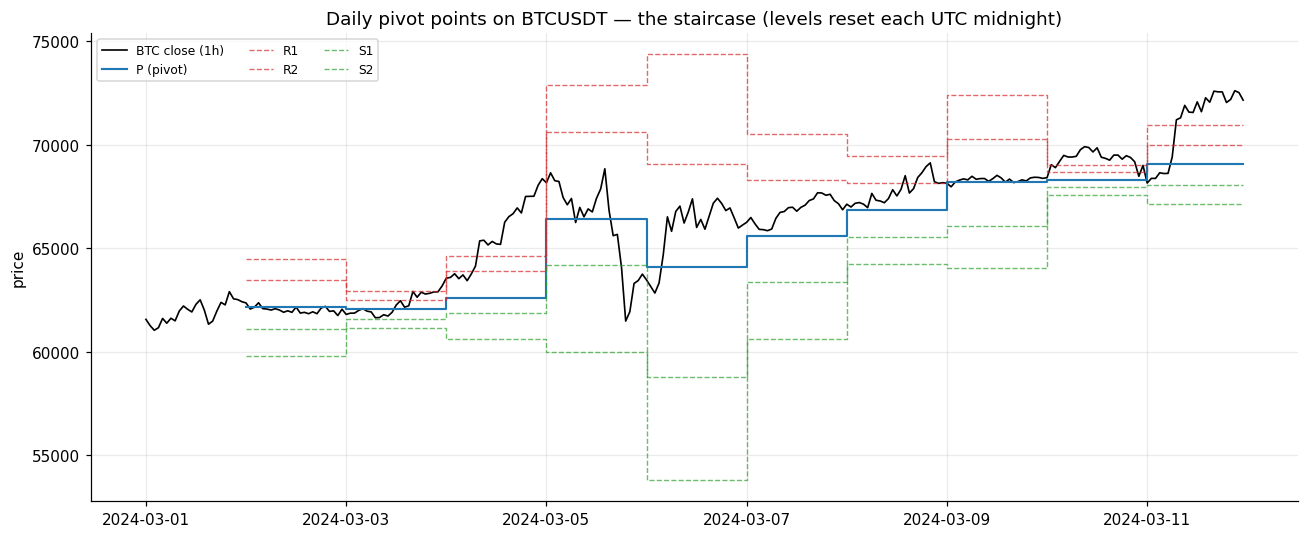

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["close"], color="black", lw=1.1, label="BTC close (1h)")
# Step-plots so the daily-flat nature is obvious.
ax.plot(df.index, piv["p"],  color="#1f77b4", lw=1.4, drawstyle="steps-post", label="P (pivot)")
for col, c in [("r1", "#d62728"), ("r2", "#d62728"), ("s1", "#2ca02c"), ("s2", "#2ca02c")]:
    ax.plot(df.index, piv[col], color=c, lw=0.9, ls="--", alpha=0.7,
            drawstyle="steps-post", label=col.upper())
ax.set_title("Daily pivot points on BTCUSDT — the staircase (levels reset each UTC midnight)")
ax.legend(ncol=3, fontsize=8, loc="upper left")
ax.set_ylabel("price")
show("01_pivots_btc")

**How to read the chart.** Black = BTC price (1h). Blue = the daily pivot $P$, red dashed = resistances $R1/R2$, green dashed = supports $S1/S2$. Each coloured line is *flat within a day* and jumps at UTC midnight — that is the staircase. Price wanders through the ladder; the strategy's bet is that when price poke *below* $S1$ (green) it tends to come back up toward $P$ (blue), and symmetrically at $R1$.

## Taking `pivot_cci` apart

The harness strategy scores composite **1.22** on BTC/ETH — but it is five ideas stacked together. Here is the long-entry logic, decomposed into atomic claims (short side is the mirror):

| # | Layer | The claim it makes |
|---|-------|--------------------|
| **H1** | **Bare pivot reversion** | `low < S1` → price reverts up toward `P`. *(the core)* |
| H2 | CCI momentum gate | require `CCI < -threshold` **and** `CCI` rising (turning up) |
| H3 | RSI gate | require `RSI < 40` (oversold confirmation) |
| H4 | EMA200 trend gate | only go long in an up-trend (`close > EMA200`) — 'load-bearing' per program.md |
| H5 | Funding gate | skip longs when funding is extremely positive |
| — | Exit | close at `P`, or when `CCI` recovers past `-40`, or on opposite signal |

**The plan.** Test **H1 alone first**, baseline-controlled and pooled — does a bare $S1/R1$ touch predict reversion to $P$ at all, before any filter? If H1 is dead, the 1.22 lives entirely in the filters (probably the trend gate = a momentum/regime effect wearing a pivot costume, exactly like RSI turned out to be a magnitude proxy). If H1 is alive, we have a real pivot phenomenon to build on. Then H2→H5 get added one at a time, each judged on **marginal** lift over the layer below.

**Next step → `02`:** the bare S1/R1 touch event-study. For every intraday bar where price trades through $S1$ (long) or $R1$ (short), measure the forward move to $P$ vs an unconditional baseline, pooled across the majors + alts on 2024 (2025 sealed), net of 0.15% cost. Prediction to state before running: if pivots are just 'a level far from recent price', the touch edge will be ≈ the plain magnitude/mean-reversion edge the `dump` line already owns — no *pivot-specific* lift.

## How the strategy actually trades (the mechanic, on real bars)

Enough theory — let's watch `pivot_cci` trade. We mark every entry/exit the **actual strategy code** produces on a real ETH window, on top of the pivots and the EMA200 trend gate. The loop to look for:

> **Long:** price *pierces S1* (green) while **above EMA200** (up-trend) and CCI is oversold-and-turning-up → buy the dip → **exit when price reverts up to P** (blue).

Nov–Dec 2024 (the post-election ETH rally) is a clean teaching window: an up-trend, so the EMA200 gate keeps the book long, and you can see dip-buys to S1 snapping back to P. The second chart then shows *why the gate is decisive* — the same strategy with and without it.

[saved] notebooks\pivots\_out\01_strategy_in_action.png
in window — long entries: 8 | short entries: 0


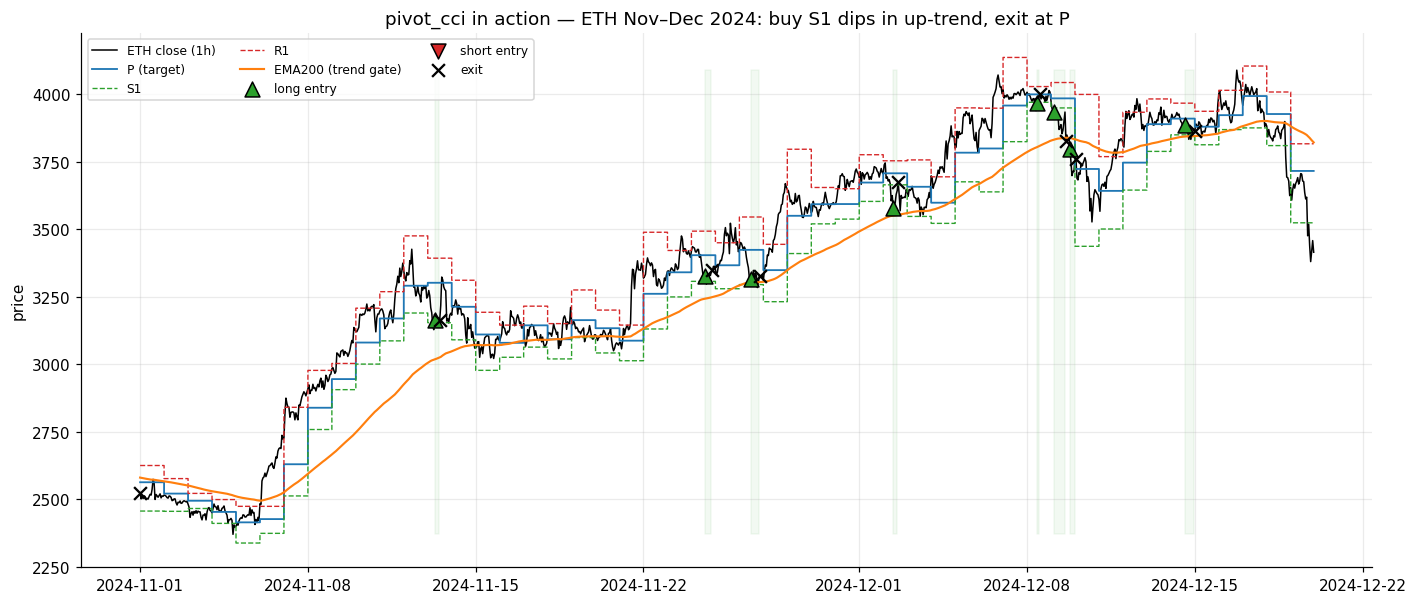

In [3]:
# --- Chart 1: the strategy trading a real ETH window (entries/exits marked) ---
warm = ohlcv("ETHUSDT", "2024-08-01", "2024-12-25", "1h")  # extra history warms EMA200
pos = strat_signals(warm, "ETHUSDT")
ema = warm["close"].ewm(span=200, adjust=False).mean()
piv2 = daily_pivots(warm)

win = (warm.index >= "2024-11-01") & (warm.index < "2024-12-20")
d, pv, em, ps = warm[win], piv2[win], ema[win], pos[win]
new_long  = (ps == 1) & (ps.shift() != 1)
new_short = (ps == -1) & (ps.shift() != -1)
exit_bar  = (ps == 0) & (ps.shift() != 0)

fig, ax = plt.subplots(figsize=(13, 5.6))
ax.plot(d.index, d["close"], color="black", lw=1.0, label="ETH close (1h)")
ax.plot(d.index, pv["p"],  color="#1f77b4", lw=1.2, drawstyle="steps-post", label="P (target)")
ax.plot(d.index, pv["s1"], color="#2ca02c", lw=0.9, ls="--", drawstyle="steps-post", label="S1")
ax.plot(d.index, pv["r1"], color="#d62728", lw=0.9, ls="--", drawstyle="steps-post", label="R1")
ax.plot(d.index, em, color="#ff7f0e", lw=1.4, label="EMA200 (trend gate)")
lo, hi = d["close"].min(), d["close"].max()
ax.fill_between(d.index, lo, hi, where=(ps.values == 1),  color="#2ca02c", alpha=0.06)
ax.fill_between(d.index, lo, hi, where=(ps.values == -1), color="#d62728", alpha=0.06)
ax.scatter(d.index[new_long],  d["close"][new_long],  marker="^", s=95, color="#2ca02c", edgecolor="k", zorder=5, label="long entry")
ax.scatter(d.index[new_short], d["close"][new_short], marker="v", s=95, color="#d62728", edgecolor="k", zorder=5, label="short entry")
ax.scatter(d.index[exit_bar],  d["close"][exit_bar],  marker="x", s=70, color="black", zorder=6, label="exit")
ax.set_title("pivot_cci in action — ETH Nov–Dec 2024: buy S1 dips in up-trend, exit at P")
ax.legend(ncol=3, fontsize=8, loc="upper left"); ax.set_ylabel("price")
show("01_strategy_in_action")
print("in window — long entries:", int(new_long.sum()), "| short entries:", int(new_short.sum()))

[saved] notebooks\pivots\_out\01_ema_effect.png
end equity — FULL: 1.156 | without EMA: 0.195


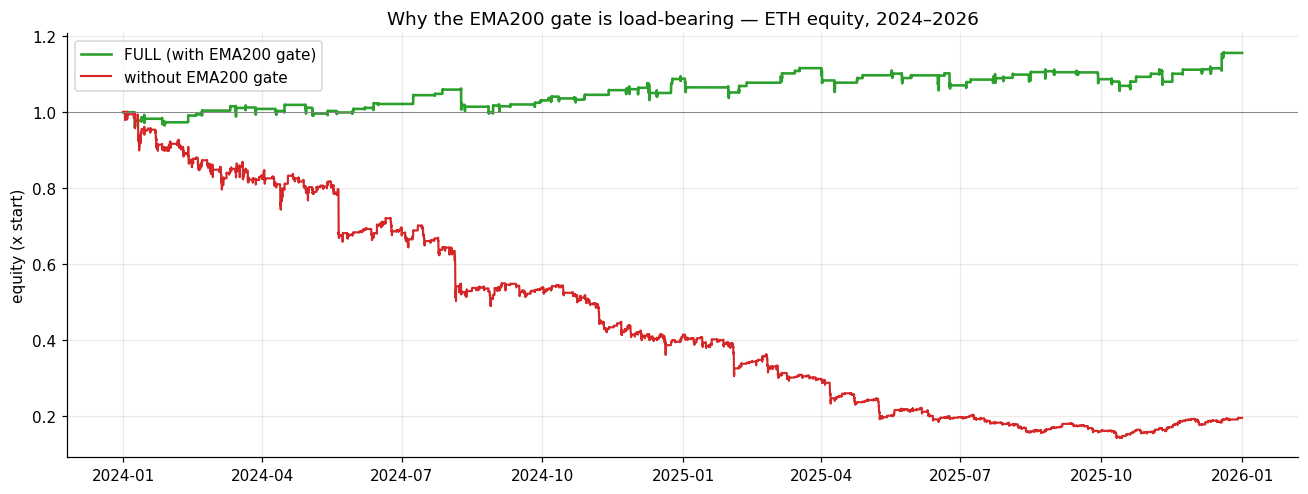

In [4]:
# --- Chart 2: why the EMA200 gate matters — equity WITH vs WITHOUT it ---
ef = ohlcv("ETHUSDT", "2024-01-01", "2026-01-01", "1h")
eq_full = (1 + backtest(strat_signals_ablated(ef, "ETHUSDT", ABL_ALL_ON), ef["close"])["net"]).cumprod()
noema = dict(ABL_ALL_ON); noema["ema"] = False
eq_noema = (1 + backtest(strat_signals_ablated(ef, "ETHUSDT", noema), ef["close"])["net"]).cumprod()

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(eq_full.index, eq_full, color="#2ca02c", lw=1.7, label="FULL (with EMA200 gate)")
ax.plot(eq_noema.index, eq_noema, color="#d62728", lw=1.4, label="without EMA200 gate")
ax.axhline(1.0, color="gray", lw=0.6)
ax.set_title("Why the EMA200 gate is load-bearing — ETH equity, 2024–2026")
ax.set_ylabel("equity (x start)"); ax.legend()
show("01_ema_effect")
print("end equity — FULL:", round(float(eq_full.iloc[-1]), 3),
      "| without EMA:", round(float(eq_noema.iloc[-1]), 3))

### How to read these two charts

**Chart 1 (mechanic).** Black = ETH price. Blue step = daily P, green/red dashed = S1/R1, orange = EMA200. Green ▲ = long entry, red ▼ = short entry, black ✕ = exit; the faint green/red shading marks when a position is held. Watch the loop: price dips and its low pierces **S1** while it sits **above EMA200** → a long fires (▲) → price mean-reverts up and the trade closes at/near **P** (✕). The strategy only takes these dips *because* EMA200 says the trend is up.

**Chart 2 (why EMA matters).** Same ETH, full 2024–2026, equity **with** vs **without** the EMA200 gate. Green (with gate) grinds up; red (no gate) collapses. Without the gate the strategy also shorts every R1 poke in an up-trend and buys every S1 dip in a down-trend — i.e. it fights the trend and gets run over. So to answer your question directly: **yes — the EMA200 gate is what turns this from a losing pattern into a working one.** It doesn't add a little; it flips the sign. Everything else (pivots, CCI, RSI) only earns *inside* the regime the gate selects.